In [1]:
from ase.io.trajectory import Trajectory, TrajectoryWriter

# 1. Load the original trajectory file
original_traj = Trajectory("../1_test/NVT-330K-ZnO_1ZnCl2_5NaCl.traj", "r")


In [18]:

# 2. Set up the writer
new_traj = TrajectoryWriter("./filtered_NVT-330K-ZnO_1ZnCl2_5NaCl.traj", mode="w")

# 3. Slice the trajectory: start at 0, stop at 4000, step by 2
# for atoms in original_traj[: 2000 * 2 : 3]:
#     new_traj.write(atoms)


for atoms in original_traj[100: 6500: 2]:
    new_traj.write(atoms)

# 4. Close the file to flush the buffer
new_traj.close()

print(f"Done! Written frames to filtered_NVT-330K-ZnO_1ZnCl2_5NaCl.traj.")

Done! Written frames to filtered_NVT-330K-ZnO_1ZnCl2_5NaCl.traj.


In [19]:
print("Number of frames:", len(original_traj))
print("Number of frames:", len(new_traj))

Number of frames: 7383
Number of frames: 3200


In [20]:
new_traj = Trajectory("filtered_NVT-330K-ZnO_1ZnCl2_5NaCl.traj", "r")

In [14]:
print(original_traj[0].get_potential_energy())
print(new_traj[0].get_potential_energy())

-3929.5205078125
-3954.525146484375


In [21]:
from pinn.io import load_ase

dataset = load_ase("filtered_NVT-330K-ZnO_1ZnCl2_5NaCl.traj", splits=None, shuffle=False)

In [22]:
import numpy as np
def extract_energies(dataset):
    energies = []
    # If the loader returns a tf.data.Dataset:
    if hasattr(dataset, "as_numpy_iterator"):
        for elem in dataset.as_numpy_iterator():
            energies.append(np.squeeze(elem["e_data"]))
    # If the loader returns a standard Python iterable/list:
    else:
        for elem in dataset:
            energies.append(np.squeeze(elem["e_data"]))
    return np.array(energies)

e_zncl2_5nacl = extract_energies(dataset)

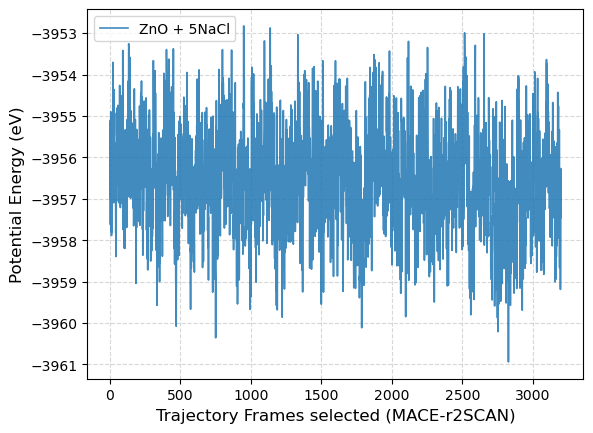

In [23]:
import matplotlib.pyplot as plt
plt.plot(e_zncl2_5nacl, label="ZnO + 5NaCl", alpha=0.85, linewidth=1.2)

plt.xlabel("Trajectory Frames selected (MACE-r2SCAN)", fontsize=12)
plt.ylabel("Potential Energy (eV)", fontsize=12)
# plt.title("Potential Energy Evolution (330K NVT)", fontsize=14)
plt.legend(frameon=True)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()